In [303]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [304]:
image_path='D:/PythonProject1/Intern/Images/image2.jpg'
image=cv2.imread(image_path)

In [305]:
lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab).astype(np.float64)
blurr=cv2.GaussianBlur(lab,(3,3),0)

In [306]:
a_channel = blurr[:, :, 1]
b_channel = blurr[:, :, 2]

In [307]:
shift_a = np.roll(a_channel, shift=3, axis=0)
shift_a = np.roll(shift_a, shift=3, axis=1)

shift_b = np.roll(b_channel, shift=3, axis=0)
shift_b = np.roll(shift_b, shift=3, axis=1)

In [308]:
edge_a = np.abs(a_channel - shift_a)
edge_b = np.abs(b_channel - shift_b)


In [309]:
final_color_edges = np.sqrt(edge_a**2 + edge_b**2)
final_normalized = cv2.normalize(final_color_edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, thresholded_edges = cv2.threshold(final_normalized, 60, 255, cv2.THRESH_BINARY)

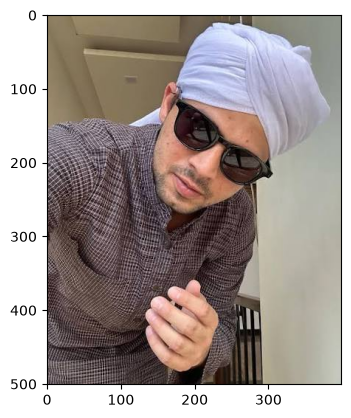

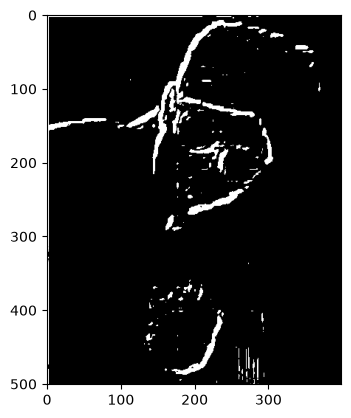

In [310]:
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(thresholded_edges,cmap='grey')
plt.show()

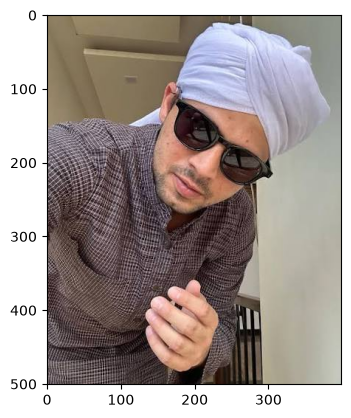

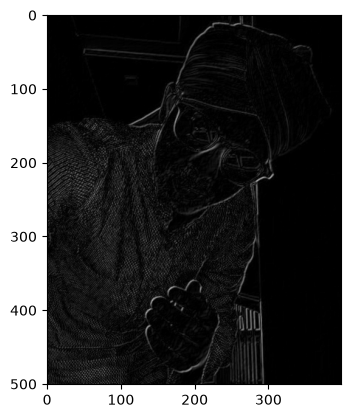

In [311]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("D:/PythonProject1/Intern/Images/image2.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (3, 3), 0)

shifted = np.roll(blurred, shift=1, axis=0)
shifted = np.roll(shifted, shift=1, axis=1).astype(np.float32)

subtract = np.abs(blurred - shifted)

edges = cv2.normalize(subtract, cv2.NORM_MINMAX)


plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow( edges,cmap='gray')
plt.show()

In [312]:
img1=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
blurred=cv2.GaussianBlur(img1,(3,3),0)
kernel=np.ones((2,2)) 

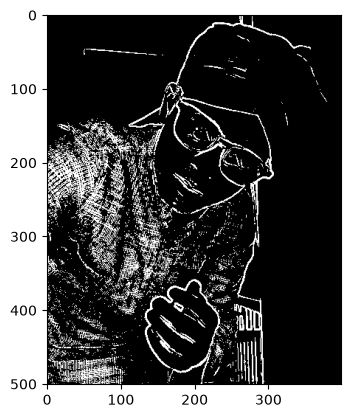

In [320]:
erosion=cv2.erode(blurred,kernel,iterations=1)
dilation=cv2.dilate(blurred,kernel,iterations=1)
edge=dilation-erosion
_, binary_edges = cv2.threshold(edge,25, 100, cv2.THRESH_BINARY) 
plt.imshow(binary_edges,cmap='grey')
plt.show()